In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#sample vector data - dimensions
embeddings ={
    "cat": [0.9, 0.1],
    "dog": [0.8, 0.2],
    "car": [0.1, 0.9],
    "kitten": [0.95, 0.05],
    "puppy": [0.85, 0.15],
    "human": [0.2, 0.8],
    "food": [0.3, 0.7]
}

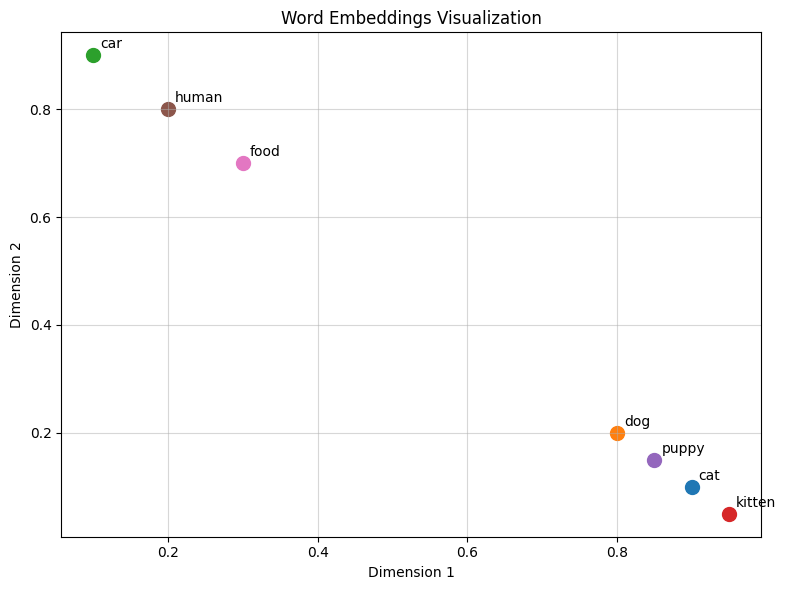

In [3]:
fig, ax =plt.subplots(figsize=(8,6)) # Create a 3D scatter plot
for word, coords in embeddings.items():
    ax.scatter(coords[0], coords[1], s=100) # Plot the point in 3D space
    ax.annotate(word, (coords[0], coords[1]), xytext=(5,5), textcoords="offset points") # Annotate the point with the word
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Word Embeddings Visualization')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# --- IGNORE ---
# explain this all code
# This code is a Python script that visualizes word embeddings in a 3D space.
# It uses the `numpy` library for numerical operations and `matplotlib` for plotting. 
# #The script defines a dictionary called `embeddings`, where each key is a word and its value is a list of three numbers 
# representing the coordinates of that word in a 3D embedding space.

In [4]:
## Measuring Similarity
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the cosine of the angle between two vectors in a multi-dimensional space.
    - Result close to 1: Vectors are very similar (pointing in the same direction).
    - Result close to 0: Vectors are orthogonal (unrelated).
    - Result close to -1: Vectors are opposite (pointing in opposite directions).
    """
    dot_product = np.dot(vec1, vec2) # Calculate the dot product of the two vectors
    norm_vec1 = np.linalg.norm(vec1) # Calculate the magnitude of the first vector
    norm_vec2 = np.linalg.norm(vec2) # Calculate the magnitude of the second vector
    if norm_vec1 == 0 or norm_vec2 == 0: # Check for zero-length vectors to avoid division by zero
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2) # Return the cosine similarity

In [5]:
#example
cat = [0.8,0.6, 0.3]
dog = [0.7,0.5, 0.4]
car = [0.1,0.2, 0.9]
puppy = [0.75,0.55, 0.35]
kitten = [0.85,0.65, 0.25]
print("Cosine similarity between cat and dog:", cosine_similarity(cat, dog)) # Similarity between cat and dog
print("Cosine similarity between cat and car:", cosine_similarity(cat, car)) # Similarity
print("Cosine similarity between cat and puppy:", cosine_similarity(cat, puppy)) # Similarity between cat and puppy
print("Cosine similarity between cat and kitten:", cosine_similarity(cat, kitten)) # Similarity


Cosine similarity between cat and dog: 0.9894448035984582
Cosine similarity between cat and car: 0.48543980353795835
Cosine similarity between cat and puppy: 0.997604842677941
Cosine similarity between cat and kitten: 0.9980416556767985


## Creating Embeddings

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
import os
load_dotenv()

## Initialize a simple embedding model (using HuggingFace)
embedding = HuggingFaceEndpointEmbeddings(
    model='sentence-transformers/all-MiniLM-L6-v2',
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
)
print("Hugging Face embedding for query:", embedding.embed_query("What is the capital of France?"))


/home/divyanshu/Desktop/RAG/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face embedding for query: [0.08204815536737442, 0.03605547919869423, -0.0038928501307964325, -0.004881061147898436, 0.02565111219882965, -0.05714341625571251, 0.012191585265100002, 0.004678942263126373, 0.03494987264275551, -0.022421881556510925, -0.008005267940461636, -0.10935357213020325, 0.022724749520421028, -0.02932085283100605, -0.043522052466869354, -0.120241180062294, -0.0008486059959977865, -0.018150174990296364, 0.05612955987453461, 0.003085269359871745, 0.0023364077787846327, -0.01683926209807396, 0.06362466514110565, -0.023660244420170784, 0.031493496149778366, -0.034797973930835724, -0.02054883912205696, -0.002791013801470399, -0.011037996038794518, -0.03612670674920082, 0.05414110794663429, -0.03661714494228363, -0.0250086709856987, -0.03817040100693703, -0.04960361495614052, -0.015148145146667957, 0.021315045654773712, -0.012740401551127434, 0.07670092582702637, 0.044355761259794235, -0.010834852233529091, -0.029759952798485756, -0.016970504075288773, -0.02469179

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
load_dotenv()
embeddings = HuggingFaceEmbeddings(
    model='sentence-transformers/all-MiniLM-L6-v2',
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3023.82it/s]


In [8]:
text = "The cat is on the roof."
embedding = embeddings.embed_query(text)
print("Length of the embedding vector:", len(embedding))
print("Embedding for the sentence:", embedding)

Length of the embedding vector: 384
Embedding for the sentence: [0.0901421308517456, 0.07564277201890945, 0.0202474482357502, 0.012722772546112537, -0.04801316186785698, -0.012389580719172955, 0.014910442754626274, 0.020820707082748413, -0.0007704976014792919, 0.02547912672162056, -0.03893270716071129, 0.051342595368623734, 0.009062439203262329, -0.008285722695291042, -0.021775707602500916, 0.00042897462844848633, -0.0677621066570282, -0.012746288441121578, 0.04464959725737572, 0.04159592092037201, -0.0027069379575550556, -0.03153903782367706, 0.019125355407595634, -0.03482213616371155, -0.04329350218176842, 0.04330149665474892, -0.06230570003390312, -0.031219156458973885, -0.00252356450073421, -0.016854319721460342, -0.016138605773448944, -0.003616910893470049, -0.07031159847974777, 0.06256607919931412, -0.014947747811675072, -0.05734643712639809, -0.000339319696649909, -0.04151362180709839, -0.01782073639333248, 0.0860837996006012, 0.03254355117678642, -0.0035632424987852573, -0.0842

In [9]:
sentences= [
    "The cat is on the roof.",
    "The dog is in the yard.",
    "The car is parked outside.",
    "I love machine learning and natural language processing.",
    "Artificial intelligence is transforming the world.",
]
sentence_embeddings = embeddings.embed_documents(sentences)
print("Embeddings for the sentences:", sentence_embeddings)

Embeddings for the sentences: [[0.09014218300580978, 0.07564275711774826, 0.020247476175427437, 0.012722773477435112, -0.04801318421959877, -0.012389563024044037, 0.014910432510077953, 0.02082068845629692, -0.000770509650465101, 0.025479117408394814, -0.0389326848089695, 0.051342617720365524, 0.009062427096068859, -0.008285769261419773, -0.021775657311081886, 0.00042899197433143854, -0.0677621066570282, -0.012746310792863369, 0.044649600982666016, 0.04159596189856529, -0.002706956584006548, -0.03153897821903229, 0.019125327467918396, -0.034822121262550354, -0.04329345002770424, 0.043301504105329514, -0.062305714935064316, -0.031219182536005974, -0.00252355495467782, -0.016854330897331238, -0.016138626262545586, -0.0036169004160910845, -0.07031162828207016, 0.06256607174873352, -0.014947723597288132, -0.05734645575284958, -0.0003393381484784186, -0.04151357710361481, -0.017820725217461586, 0.0860837996006012, 0.03254355490207672, -0.0035632450599223375, -0.0842222049832344, -0.029802124

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

